In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Products.csv')
df.head(3)

,CustomerId,Product_Type,Enrollment_Date,Status
0,15634602,Credit Card,2022-05-04,Active
1,15634602,Insurance,2023-05-01,Active
2,15634602,Mutual Fund,2023-12-21,Active


In [3]:
print(df.info())
display(df.describe(include="all").T)
nulls=df.isna().mean().sort_values(ascending=False)
display(nulls.to_frame("nulls_ratio"))
uniqs=(df.nunique().sort_values(ascending=False))
display(uniqs.to_frame("Unique_Counnts"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20068 entries, 0 to 20067
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerId       20068 non-null  int64 
 1   Product_Type     20068 non-null  object
 2   Enrollment_Date  20068 non-null  object
 3   Status           20068 non-null  object
dtypes: int64(1), object(3)
memory usage: 627.3+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerId,20068.0,NaN,NaN,NaN,15690686.793353,71698.069381,15565701.0,15628303.0,15690664.0,15752632.0,15815690.0
Product_Type,20068,5,Credit Card,4074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Enrollment_Date,20068,730,2023-03-13,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,20068,2,Active,16080,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,nulls_ratio
CustomerId,0.0
Product_Type,0.0
Enrollment_Date,0.0
Status,0.0


,Unique_Counnts
CustomerId,10000
Enrollment_Date,730
Product_Type,5
Status,2


In [4]:
df.duplicated().sum()

0

In [5]:
import matplotlib.pyplot as plt

In [7]:
df.groupby('CustomerId')['Product_Type'].nunique().reset_index()

,CustomerId,Product_Type
0,15565701,2
1,15565706,3
2,15565714,1
3,15565779,2
4,15565796,2
...,...,...
9995,15815628,2
9996,15815645,1
9997,15815656,3
9998,15815660,2


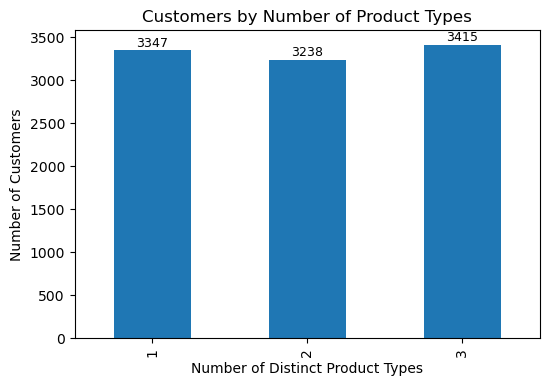

In [9]:
# Step 1: Count distinct products per customer
prod_count = df.groupby('CustomerId')['Product_Type'].nunique().reset_index()
prod_count.columns = ['CustomerId', 'Distinct_Product_Count']

# Step 2: Count customers by number of distinct products
prod_distribution = prod_count['Distinct_Product_Count'].value_counts().sort_index()

# Step 3: Plot
prod_distribution.plot(kind='bar', figsize=(6,4), title='Customers by Number of Product Types')

ax = prod_distribution.plot(kind='bar', figsize=(6,4), title='Customers by Number of Product Types')
plt.xlabel('Number of Distinct Product Types')
plt.ylabel('Number of Customers')

for i, v in enumerate(prod_distribution):
    ax.text(i, v + 50, str(v), ha='center', fontsize=9)
plt.show()
